In [ ]:
# Copyright 2026 Syed Basim Ali
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.float_format = '{:_.2f}'.format
pd.set_option("display.expand_frame_repr", False)

In [12]:
%run get_recent_results.py

Skipped copying, destination is up to date.
Skipped copying, destination is up to date.
Skipped copying, destination is up to date.
Skipped copying, destination is up to date.


In [13]:
plot_dir = "plots/bench_op_f"
os.makedirs(plot_dir, exist_ok=True)

In [14]:
df_64 = pd.read_csv("bench_op_f_float64.csv")
df_32 = pd.read_csv("bench_op_f_float32.csv")

df_64_mean_sq = df_64[df_64["VARIANT"] == "RunningMeanSqBuffer"]
df_64_mean = df_64[df_64["VARIANT"] == "RunningMeanBuffer"]

df_32_mean_sq = df_32[df_32["VARIANT"] == "RunningMeanSqBuffer"]
df_32_mean = df_32[df_32["VARIANT"] == "RunningMeanBuffer"]

df_dict = {
    "df_64_mean_sq": df_64_mean_sq,
    "df_64_mean": df_64_mean,
    "df_32_mean_sq": df_32_mean_sq,
    "df_32_mean": df_32_mean,
}

In [15]:
# df = df[df['BLOCK_SIZE'] == 1024]
# df = df[df['CALC_EVERY'] == 1]
# df = df[df['CALC_EVERY'] < 48]
# df = df[df['MAXLEN'] == 4_194_304]
# df = df[df["VARIANT"] != 'RunningMeanBuffer']

In [16]:
for name, df in df_dict.items():
    print(f"\n{name}\n{df}")


df_64_mean_sq
                  VARIANT           MODE   MAXLEN     TIME  BLOCK_SIZE  NUM_RUNS  CALC_EVERY
1     RunningMeanSqBuffer  extend/append      512     3276           8       260           1
3     RunningMeanSqBuffer    calculation      512     3464           8       260           1
5     RunningMeanSqBuffer  extend/append      512     1823           8       260           2
7     RunningMeanSqBuffer    calculation      512     3443           8       260           2
9     RunningMeanSqBuffer  extend/append      512     1305           8       260           3
...                   ...            ...      ...      ...         ...       ...         ...
9591  RunningMeanSqBuffer    calculation  8388608  1271383      524288       260          32
9593  RunningMeanSqBuffer  extend/append  8388608   218654      524288       260          48
9595  RunningMeanSqBuffer    calculation  8388608  1297793      524288       260          48
9597  RunningMeanSqBuffer  extend/append  8388608   225

In [17]:
for name, df in df_dict.items():
     print(f"\n{name}\n{df.describe()}")


df_64_mean_sq
            MAXLEN         TIME  BLOCK_SIZE  NUM_RUNS  CALC_EVERY
count     4_800.00     4_800.00    4_800.00  4_800.00    4_800.00
mean  1_420_807.68    83_827.71   31_451.56    260.00       18.33
std   2_440_708.93   205_485.88   93_734.02      0.00       19.36
min         512.00       470.00        8.00    260.00        1.00
25%      16_384.00     4_251.50       64.00    260.00        3.75
50%     262_144.00     7_504.00      512.00    260.00       10.00
75%   2_097_152.00    63_421.50    8_192.00    260.00       26.00
max   8_388_608.00 1_783_475.00  524_288.00    260.00       64.00

df_64_mean
            MAXLEN         TIME  BLOCK_SIZE  NUM_RUNS  CALC_EVERY
count     4_800.00     4_800.00    4_800.00  4_800.00    4_800.00
mean  1_420_807.68   181_097.45   31_451.56    260.00       18.33
std   2_440_708.93   611_635.10   93_734.02      0.00       19.36
min         512.00       497.00        8.00    260.00        1.00
25%      16_384.00     8_750.75       64.00    26


df_64_mean_sq


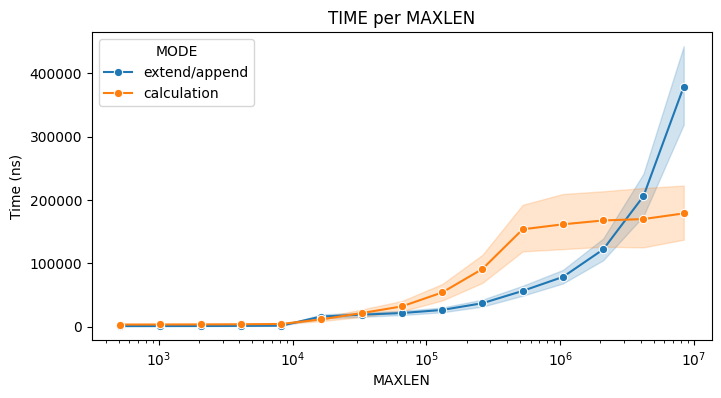


df_64_mean


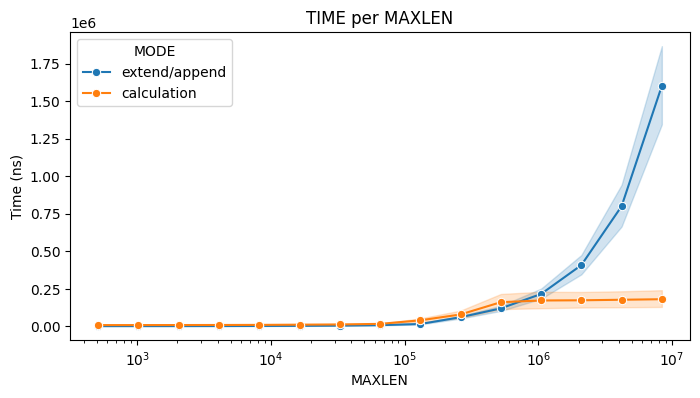


df_32_mean_sq


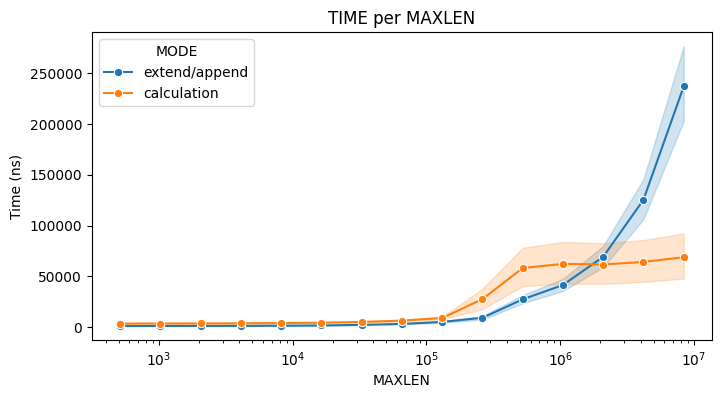


df_32_mean


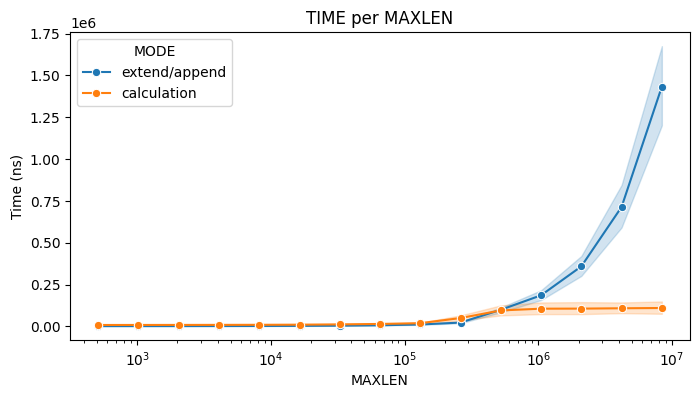

In [18]:
for name, df in df_dict.items():
    print(f"\n{name}")
    plt.figure(figsize=(8,4))
    sns.lineplot(data=df, x='MAXLEN', y='TIME', hue='MODE', marker='o')
    plt.xlabel('MAXLEN')
    plt.ylabel('Time (ns)')
    plt.title('TIME per MAXLEN')
    plt.xscale('log')
    plt.show()
    plt.close()


df_64_mean_sq


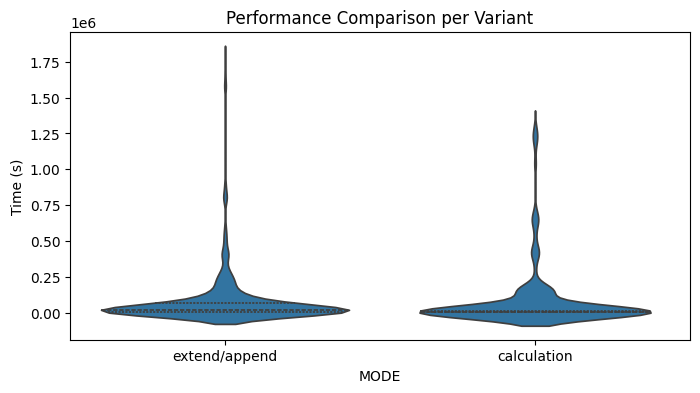


df_64_mean


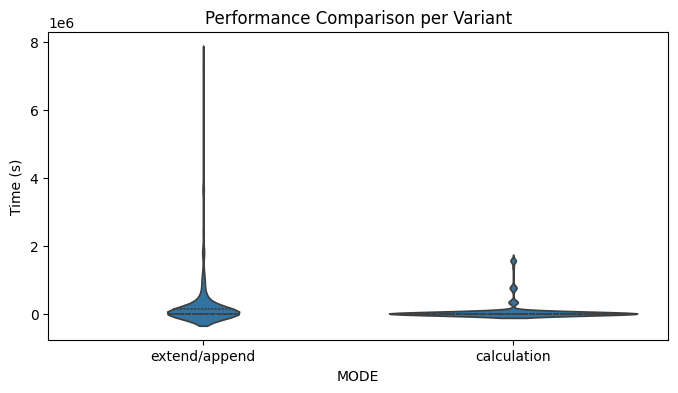


df_32_mean_sq


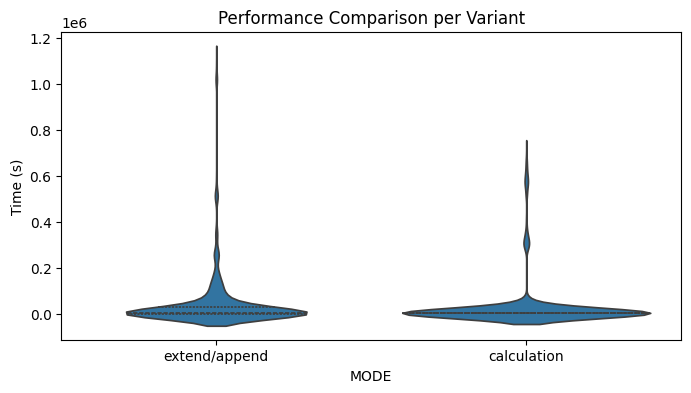


df_32_mean


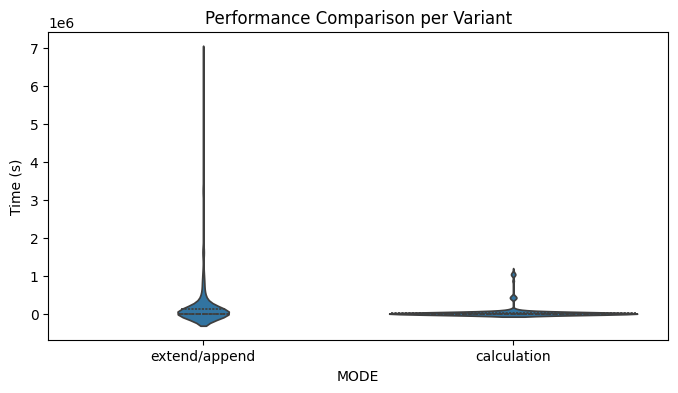

In [19]:
for name, df in df_dict.items():
    print(f"\n{name}")
    plt.figure(figsize=(8,4))
    sns.violinplot(data=df, x='MODE', y='TIME', inner="quartile")
    plt.ylabel("Time (s)")
    plt.title("Performance Comparison per Variant")
    plt.show()
    plt.close()



df_64_mean_sq

--- BLOCK_SIZE ---

min rel = 0.283 at BLOCK_SIZE = 524_288
max rel = 12.003 at BLOCK_SIZE = 8


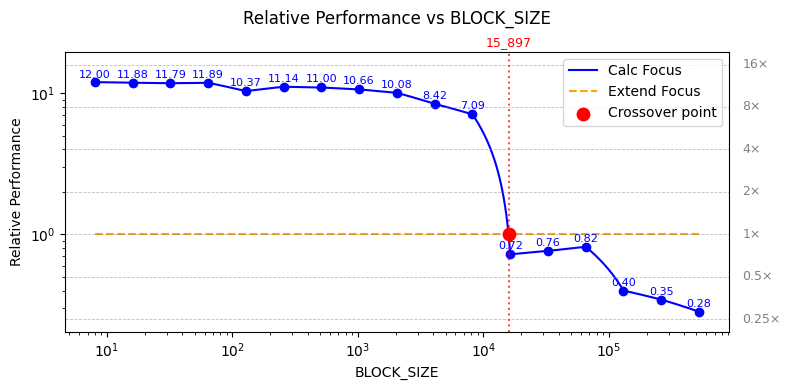

Crossover(s) occur at BLOCK_SIZE ≈ 15_897(-)

 --------------------

--- CALC_EVERY ---

min rel = 0.209 at CALC_EVERY = 48
max rel = 3.557 at CALC_EVERY = 1


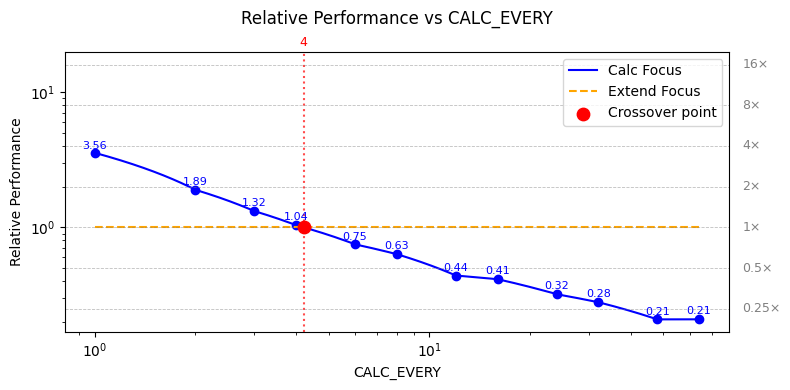

Crossover(s) occur at CALC_EVERY ≈ 4(-)

 --------------------

--- MAXLEN ---

min rel = 0.303 at MAXLEN = 512
max rel = 2.119 at MAXLEN = 8_388_608


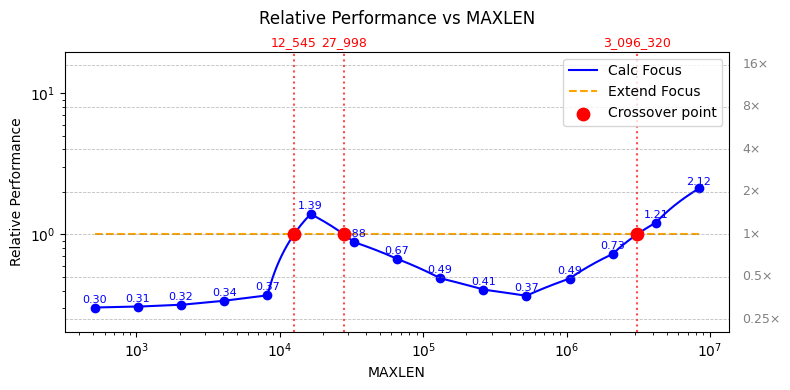

Crossover(s) occur at MAXLEN ≈ 12_545(+), 27_998(-), 3_096_320(+)

 --------------------


df_64_mean

--- BLOCK_SIZE ---

min rel = 0.459 at BLOCK_SIZE = 524_288
max rel = 23.067 at BLOCK_SIZE = 16


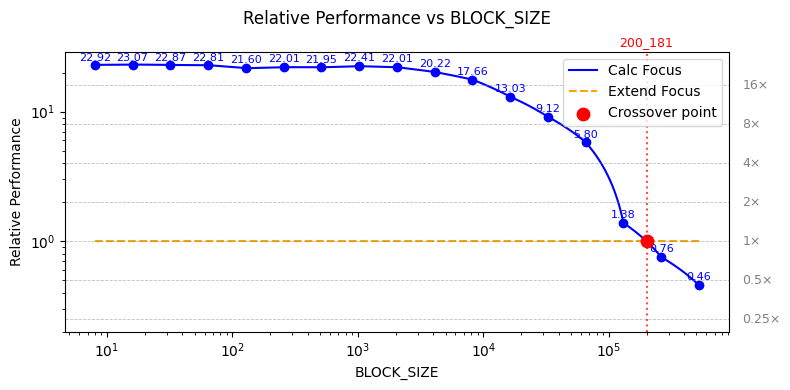

Crossover(s) occur at BLOCK_SIZE ≈ 200_181(-)

 --------------------

--- CALC_EVERY ---

min rel = 0.372 at CALC_EVERY = 64
max rel = 13.881 at CALC_EVERY = 1


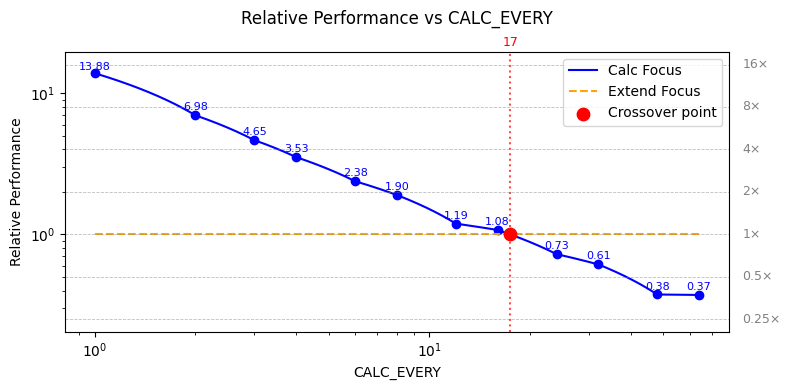

Crossover(s) occur at CALC_EVERY ≈ 17(-)

 --------------------

--- MAXLEN ---

min rel = 0.211 at MAXLEN = 512
max rel = 8.866 at MAXLEN = 8_388_608


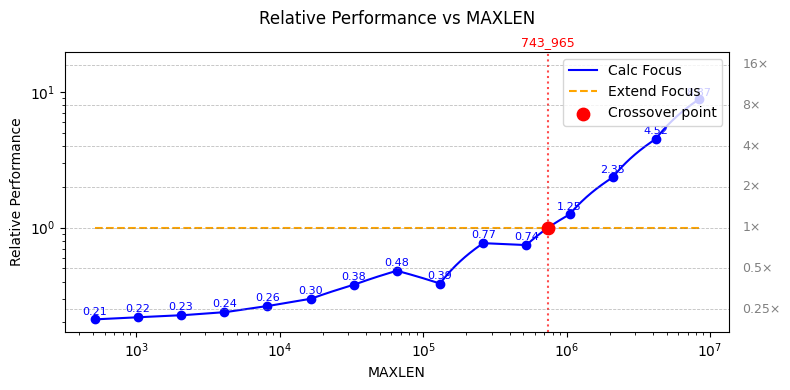

Crossover(s) occur at MAXLEN ≈ 743_965(+)

 --------------------


df_32_mean_sq

--- BLOCK_SIZE ---

min rel = 0.315 at BLOCK_SIZE = 524_288
max rel = 8.557 at BLOCK_SIZE = 8


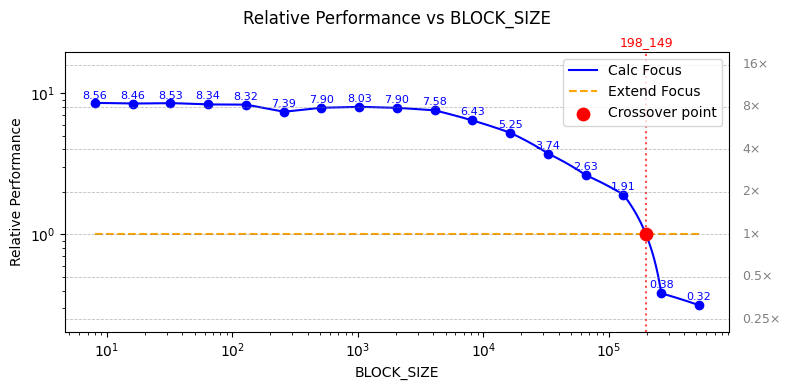

Crossover(s) occur at BLOCK_SIZE ≈ 198_149(-)

 --------------------

--- CALC_EVERY ---

min rel = 0.306 at CALC_EVERY = 64
max rel = 5.790 at CALC_EVERY = 1


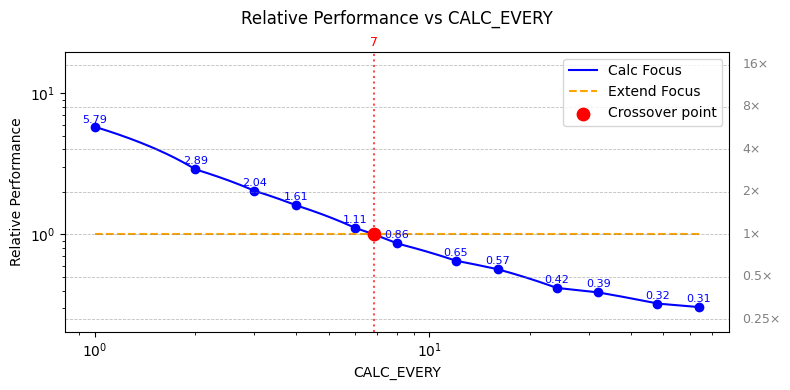

Crossover(s) occur at CALC_EVERY ≈ 7(-)

 --------------------

--- MAXLEN ---

min rel = 0.286 at MAXLEN = 512
max rel = 3.451 at MAXLEN = 8_388_608


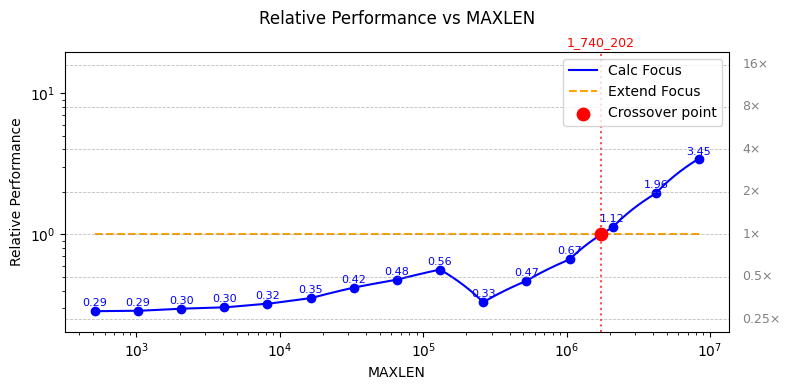

Crossover(s) occur at MAXLEN ≈ 1_740_202(+)

 --------------------


df_32_mean

--- BLOCK_SIZE ---

min rel = 0.590 at BLOCK_SIZE = 524_288
max rel = 20.854 at BLOCK_SIZE = 16


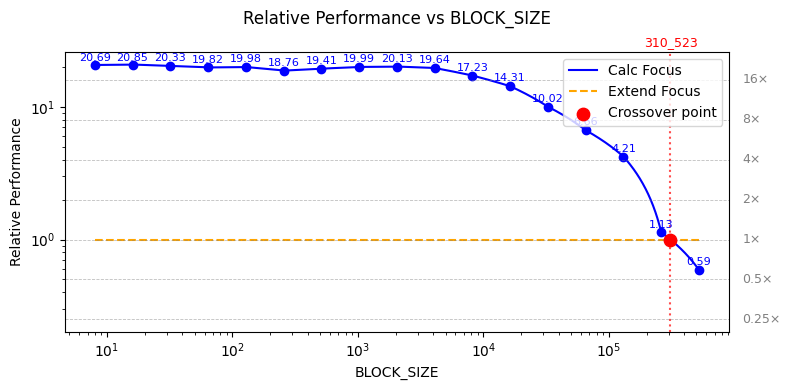

Crossover(s) occur at BLOCK_SIZE ≈ 310_523(-)

 --------------------

--- CALC_EVERY ---

min rel = 0.460 at CALC_EVERY = 64
max rel = 19.864 at CALC_EVERY = 1


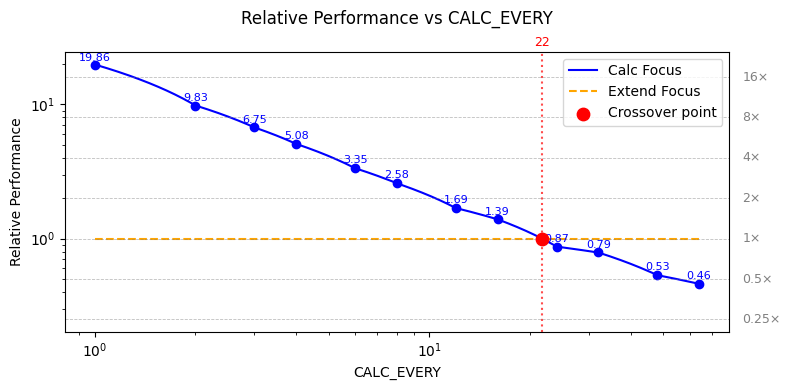

Crossover(s) occur at CALC_EVERY ≈ 22(-)

 --------------------

--- MAXLEN ---

min rel = 0.208 at MAXLEN = 512
max rel = 13.065 at MAXLEN = 8_388_608


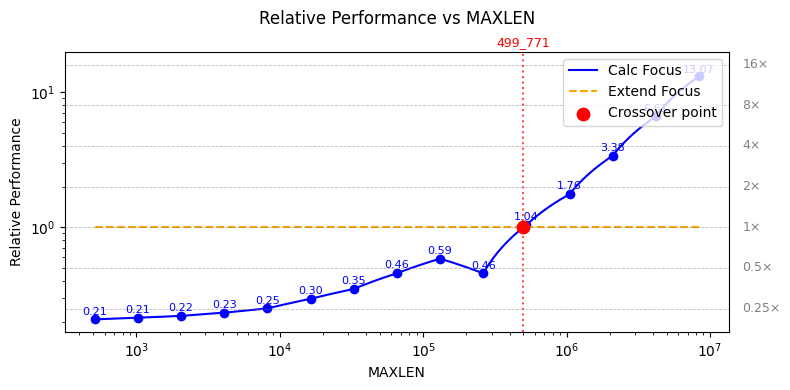

Crossover(s) occur at MAXLEN ≈ 499_771(+)

 --------------------


In [20]:
METRICS = [
    "BLOCK_SIZE",
    "CALC_EVERY",
    "MAXLEN",
]

for name, df in df_dict.items():
    print(f"\n\n{name}")

    df_pivot = df.pivot(
        index=['BLOCK_SIZE', 'CALC_EVERY', 'MAXLEN', 'NUM_RUNS'],
        columns='MODE',
        values='TIME'
    ).reset_index()

    for metric in METRICS:
        df_grouped = df_pivot.groupby(metric).mean().reset_index()
        df_grouped['rel'] = df_grouped['extend/append'] / df_grouped['calculation']

        min_idx = df_grouped['rel'].idxmin()
        max_idx = df_grouped['rel'].idxmax()

        min_val = df_grouped.loc[min_idx, 'rel']
        max_val = df_grouped.loc[max_idx, 'rel']

        min_x = df_grouped.loc[min_idx, metric]
        max_x = df_grouped.loc[max_idx, metric]

        print(f"\n--- {metric} ---\n")
        print(f"min rel = {min_val:.3f} at {metric} = {min_x:_}")
        print(f"max rel = {max_val:.3f} at {metric} = {max_x:_}")

        x = df_grouped[metric].values
        y_numpy = df_grouped['rel'].values

        x_smooth = np.logspace(np.log10(x.min()), np.log10(x.max()), 1000)
        y_numpy_smooth = np.interp(np.log10(x_smooth), np.log10(x), y_numpy)

        tol = 0.01
        above = y_numpy_smooth > 1.0
        cross_indices = np.where(np.diff(above.astype(int)) != 0)[0]  # all sign changes

        window = 10  # samples before/after to check whether curve is sufficiently away from 1    
        crossovers_with_dir = []

        # Compute gradient
        dx = x_smooth[1] - x_smooth[0]  # spacing (approx)
        dy_all = np.gradient(y_numpy_smooth, dx)

        for idx in cross_indices:
            before = y_numpy_smooth[max(0, idx - window + 1): idx + 1]
            after  = y_numpy_smooth[idx + 1: idx + 1 + window]

            before_mean = before.mean() if before.size else np.nan
            after_mean  = after.mean()  if after.size  else np.nan

            valid = ((before_mean < 1 - tol and after_mean > 1 + tol) or
                    (before_mean > 1 + tol and after_mean < 1 - tol))

            if not valid:
                continue

            x0, x1 = x_smooth[idx], x_smooth[idx + 1]
            y0, y1 = y_numpy_smooth[idx], y_numpy_smooth[idx + 1]
            logx0, logx1 = np.log10(x0), np.log10(x1)

            # linear interpolation to find exact x where y==1
            if (y1 - y0) != 0:
                logx_cross = logx0 + (1.0 - y0) * (logx1 - logx0) / (y1 - y0) 
            else: 
                0.5*(logx0+logx1)
            x_cross = 10 ** logx_cross

            # local slope at the crossover
            direction = "(+)" if dy_all[idx] > 0 else "(-)"

            y_cross = 1.0
            crossovers_with_dir.append((x_cross, y_cross, direction))

        fig, ax = plt.subplots(figsize=(8,4))

        ax.plot(x_smooth, y_numpy_smooth, label='Calc Focus', color='blue')
        ax.scatter(x, y_numpy, color='blue')
        ymax = ax.get_ylim()[1]
        for xi, yi in zip(x, y_numpy):
            y_text = min(yi*1.05, ymax*0.98)
            ax.text(xi, y_text, f"{yi:.2f}", fontsize=8, ha='center', va='bottom', color='blue')
        ax.plot(x_smooth, np.ones_like(x_smooth), label='Extend Focus', color='orange', linestyle='--')

        if crossovers_with_dir:
            for i, (cx, cy, d) in enumerate(crossovers_with_dir):
                ax.scatter(cx, cy, color='red', s=80, zorder=5, label='Crossover point' if i == 0 else None)
                ax.axvline(cx, color='red', linestyle=':', alpha=0.7)
                ax.text(cx, cy*1.02, f"{round(cx):_}", color='red', fontsize=9,
                        ha='center', transform=ax.get_xaxis_transform())

        ref_lines = [0.25, 0.5, 1, 2, 4, 8, 16]
        for r in ref_lines:
            ax.axhline(r, color='gray', linestyle='--', linewidth=0.6, alpha=0.5)
            ax.text(1.02, r, f"{r}×", va='center', ha='left', color='gray',
                    fontsize=9, transform=ax.get_yaxis_transform())

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(metric)
        ax.set_ylabel('Relative Performance')
        ax.set_title(f'Relative Performance vs {metric}', pad=20)
        ax.legend(loc='upper right')
        plt.tight_layout()
        plt.show()

        filename = os.path.join(plot_dir, f"{name}_{metric}.png")
        fig.savefig(filename, dpi=300)

        plt.close()

        if crossovers_with_dir:
            crosses_str = ", ".join(f"{round(cx):_}{dir}" for cx, _, dir in crossovers_with_dir)
            print(f"Crossover(s) occur at {metric} ≈ {crosses_str}\n\n", "-"*20)
        else:
            print(f"No crossover for {metric}\n\n", "-"*20)